<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/PERCEPTRONMULTICAPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA


In [22]:

import numpy as np
from google.colab import files
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C


In [2]:
dt = files.upload()

Saving Heart Prediction Quantum Dataset.csv to Heart Prediction Quantum Dataset.csv


In [3]:
df = pd.read_csv('Heart Prediction Quantum Dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [5]:
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'HeartRate'}>,
        <Axes: title={'center': 'QuantumPatternFeature'}>],
       [<Axes: title={'center': 'HeartDisease'}>, <Axes: >, <Axes: >]],
      dtype=object)

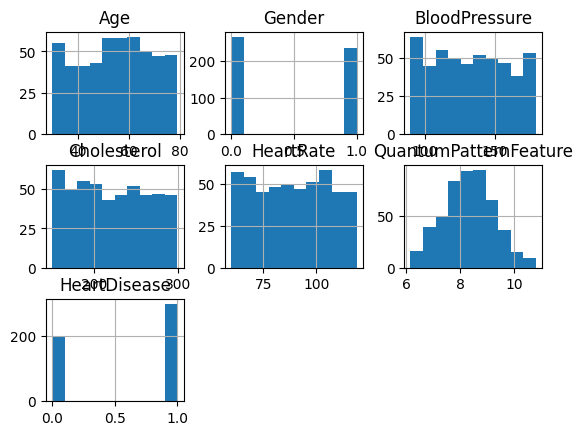

In [6]:
#ANALIZAMOS LA DISTRIBUCIÓN
df.hist()

INGIENERÍA DE CARACTERES

In [7]:
#Separamos por tipo de columna
numericos = ['Age',	'BloodPressure',	'Cholesterol'	,'HeartRate']
categoricos = ['Gender']
x = df[numericos + categoricos]
y = df['HeartDisease']



In [8]:
#Escalador
escaler = StandardScaler()
#Modelo
modelo = MLPClassifier(hidden_layer_sizes= (5,10),random_state=42) #dos capas

ENTRENAMOS

In [9]:
preprocesor = ColumnTransformer(transformers=[('num', escaler, numericos)])
pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', modelo)])
pipeline.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

METRICOS Area bajo la curva de ROC

In [10]:
#accuracy
pipeline.score(x,y)

0.778

In [11]:
#cross validation
scores = pd.DataFrame(cross_val_score(pipeline, x, y, cv=10, scoring='roc_auc_ovo'), columns=['roc_auc'])
scores.mean()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

,0
roc_auc,0.829


In [12]:
scores.describe()

,roc_auc
count,10.000000
mean,0.829000
std,0.072760
min,0.646667
25%,0.825833
50%,0.855000
75%,0.871667
max,0.886667


OPTIMIZACIÓN

In [29]:
#función a optimizar
def f(s):

  neuronas = tuple(int(val) for val in s)
  modelo = MLPClassifier(hidden_layer_sizes=neuronas, random_state=42)
  pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', modelo)])
  pipeline.fit(x,y)
  scores = pd.DataFrame(cross_val_score(pipeline, x, y, cv=10, scoring='roc_auc_ovo'), columns=['roc_auc'])
  return scores.mean()

In [36]:
#Modelo de optimización Gaussiana
kernel = 1 * RBF(length_scale=1.0)
#Al parecer el suiguiente kernel es mejor en este caso:
#kernel = C(1.0) * Matern(length_scale=1.0, nu=1.5)
gpr = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=10)



In [31]:
#puntos para arrancar
n_initial = 3
X_hist = np.zeros((n_initial, 3))
y_hist = np.zeros(n_initial)


In [32]:
#PUNTOS INICIALES PARA ARRANCAR...
for i in range(n_initial):
    x_val = np.random.uniform(2,6)
    t_val = np.random.uniform(5,15)
    z_val = np.random.uniform(3,6)
    X_hist[i] = [x_val, t_val, z_val]
    y_hist[i] = f(X_hist[i])

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [33]:
print(X_hist)
print(y_hist)


[[ 5.81298975  5.37473327  3.34436563]
 [ 5.3588731   9.16715828  3.80804003]
 [ 3.14550558 14.22989705  4.58825898]]
[0.79591667 0.82641667 0.79675   ]


In [39]:
for i in range(80):
  gpr.fit(X_hist, y_hist)#ENTRENAMOS CON LO RECOPILADO

#Creamos todos los puntos para predecir
  x_pred = np.linspace(2, 6, 7000)
  t_pred = np.linspace(5, 15, 7000)
  z_pred = np.linspace(3, 6, 7000)
  X_pred_matrix = np.column_stack((x_pred, t_pred, z_pred))

  y_pred, sigma = gpr.predict(X_pred_matrix, return_std=True)


  indice_max_y = np.argmax(y_pred) #Buscamos el elemento más alto
  nuevo_punto = X_pred_matrix[indice_max_y]
  nuevo_y = f(nuevo_punto)

  #lo agregamos
  X_hist = np.vstack([X_hist, nuevo_punto])
  y_hist= np.append(y_hist, nuevo_y)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/l

In [41]:
#ANALIZAMOS Y MOSTRAMOS EL MEJOR RESULTADO
mejor_indice = np.argmax(y_hist)
mejores_hiperparametros = np.round(X_hist[mejor_indice]).astype(int)
print(f"Mejor combinación de capas: {mejores_hiperparametros}")
print(f"Mejor ROC AUC obtenido:     {y_hist[mejor_indice]:.6f}")

Mejor combinación de capas: [ 5 14  6]
Mejor ROC AUC obtenido:     0.846000


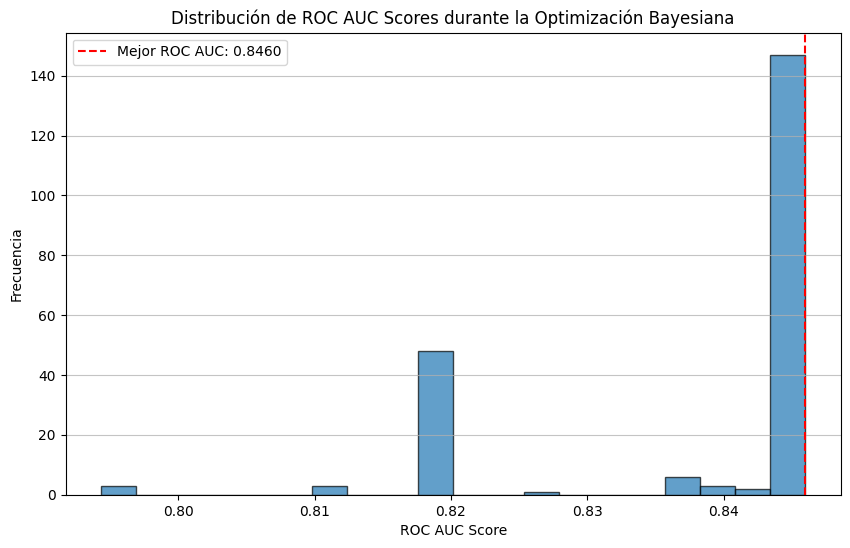

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y_hist, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=y_hist[mejor_indice], color='red', linestyle='--', label=f'Mejor ROC AUC: {y_hist[mejor_indice]:.4f}')
plt.title('Distribución de ROC AUC Scores durante la Optimización Bayesiana')
plt.xlabel('ROC AUC Score')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()